In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import Patch
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Graph Neural Network libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## Load Data

In [ ]:
try:
    print("\nLoading data files...")

    # Load price data
    prices = pd.read_csv('pharma_prices.csv', index_col=0, parse_dates=True)
    print(f"  ✓ Prices: {prices.shape}")

    # Load node features
    node_features = pd.read_csv('node_features.csv', index_col=0)
    print(f"  ✓ Node features: {node_features.shape}")

    # Load strong pairs
    strong_pairs_df = pd.read_csv('strong_pairs.csv')
    print(f"  ✓ Strong pairs: {len(strong_pairs_df)} cointegrated")

    # Load correlation matrix
    try:
        correlation_matrix = pd.read_csv('correlation_matrix.csv', index_col=0)
        print(f"  ✓ Correlation matrix: {correlation_matrix.shape}")
    except FileNotFoundError:
        print("  ⚠ Correlation matrix not found, computing from prices...")
        prices_returns = prices.pct_change().dropna()
        correlation_matrix = prices_returns.corr()
        correlation_matrix.to_csv('correlation_matrix.csv')

    # Load training results - MOST CRITICAL
    try:
        all_pairs_results = pd.read_csv('all_pairs_results.csv')
        print(f"  ✓ Training results: {len(all_pairs_results)} pairs")
    except FileNotFoundError:
        print("  ✗ WARNING: Training results not found. Creating dummy results.")
        print("    This should only happen on first run before Notebook 3 completes.")
        all_pairs_results = pd.DataFrame({
            'Ticker1': strong_pairs_df['Ticker1'],
            'Ticker2': strong_pairs_df['Ticker2'],
            'TotalRealizedPnL': np.random.randn(len(strong_pairs_df)) * 10,
            'WinRate': np.random.uniform(40, 100, len(strong_pairs_df)),
            'TotalTrades': np.random.randint(10, 50, len(strong_pairs_df))
        })

    # Validate column names
    required_cols = ['Ticker1', 'Ticker2', 'TotalRealizedPnL', 'WinRate', 'TotalTrades']
    missing_cols = [c for c in required_cols if c not in all_pairs_results.columns]

    if missing_cols:
        print(f"  ⚠ WARNING: Missing columns {missing_cols}")
        # Try to handle alternative column names
        col_map = {
            'Pair': 'Ticker1-Ticker2',
            'PnL': 'TotalRealizedPnL',
            'Total_Realized_PnL': 'TotalRealizedPnL',
            'Win_Rate': 'WinRate',
            'Total_Trades': 'TotalTrades'
        }
        for alt, std in col_map.items():
            if alt in all_pairs_results.columns and std not in all_pairs_results.columns:
                all_pairs_results.rename(columns={alt: std}, inplace=True)
                print(f"    Renamed {alt} to {std}")

except Exception as e:
    print(f"  ✗ ERROR: {e}")
    print("  Make sure you ran Notebooks 1-3 first!")
    raise

# Extract ticker list
tickers = list(prices.columns)
n_nodes = len(tickers)

print(f"\n✓ DATA LOADED:")
print(f"  Total assets: {n_nodes}")
print(f"  Total possible pairs: {n_nodes * (n_nodes - 1) // 2}")


Loading data files...
  ✓ Prices: (1467, 39)
  ✓ Node features: (39, 5)
  ✓ Strong pairs: 36 cointegrated
  ✓ Correlation matrix: (39, 39)
  ✓ Training results: 36 pairs
  ⚠ WARNING: Missing columns ['TotalRealizedPnL', 'WinRate', 'TotalTrades']
    Renamed Pair to Ticker1-Ticker2
    Renamed Total_Realized_PnL to TotalRealizedPnL
    Renamed Win_Rate to WinRate
    Renamed Total_Trades to TotalTrades

✓ DATA LOADED:
  Total assets: 39
  Total possible pairs: 741


## FEATURE PREPARATION & ALIGNMENT

In [ ]:
# Ensure node features aligned with ticker order
node_features = node_features.loc[tickers]
node_features_scaled = StandardScaler().fit_transform(node_features)
node_features_tensor = torch.tensor(node_features_scaled, dtype=torch.float32)

print(f"\n✓ Node Features:")
print(f"  Shape: {node_features_tensor.shape}")
print(f"  Nodes: {node_features_tensor.shape[0]} assets")
print(f"  Features per node: {node_features_tensor.shape[1]}")
print(f"  Columns: {list(node_features.columns)}")

# Compute returns for correlation matrix
prices_returns = prices.pct_change().dropna()
n_nodes = len(tickers)


✓ Node Features:
  Shape: torch.Size([39, 5])
  Nodes: 39 assets
  Features per node: 5
  Columns: ['Mean_Return', 'Volatility', 'Sharpe', 'Skewness', 'Kurtosis']


## GRAPH CONSTRUCTIONMULTI-TYPE EDGE CONSTRUCTION

In [ ]:
edge_list = []
edge_weights = []
edge_types = []

# 1. COINTEGRATION EDGES (Highest Priority)
print("\n1. Adding Cointegration Edges...")
cointegration_edges = 0

for idx, row in strong_pairs_df.iterrows():
    ticker1 = row['Ticker1']
    ticker2 = row['Ticker2']

    if ticker1 in tickers and ticker2 in tickers:
        i = tickers.index(ticker1)
        j = tickers.index(ticker2)

        # Weight: Lower p-value = higher weight (1.0 - p_value)
        p_value = row['PValue'] if 'PValue' in row.index else row['P_Value']
        weight = 1.0 - min(p_value, 0.05)
        weight = max(weight, 0.5)

        # Bidirectional edges
        edge_list.append([i, j])
        edge_list.append([j, i])
        edge_weights.extend([weight, weight])
        edge_types.extend(['cointegrated', 'cointegrated'])
        cointegration_edges += 2

print(f"   ✓ Added {cointegration_edges} cointegration edges")

# 2. CORRELATION EDGES (Medium Priority)
print("\n2. Adding Correlation Edges...")
correlation_matrix_values = prices_returns.corr().values
correlation_edges = 0

for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        corr_strength = abs(correlation_matrix_values[i, j])

        if corr_strength > 0.6 and [i, j] not in edge_list:
            weight = corr_strength * 0.5

            edge_list.append([i, j])
            edge_list.append([j, i])
            edge_weights.extend([weight, weight])
            edge_types.extend(['correlated', 'correlated'])
            correlation_edges += 2

print(f"   ✓ Added {correlation_edges} correlation edges")

# 3. Ensure Connectivity
print("\n3. Ensuring Graph Connectivity...")
if len(edge_list) == 0:
    print("   ⚠ Warning: No edges found! Creating linear connectivity...")
    for i in range(n_nodes - 1):
        edge_list.append([i, i + 1])
        edge_list.append([i + 1, i])
        edge_weights.extend([1.0, 1.0])
        edge_types.extend(['default', 'default'])

# 4. Convert to PyTorch tensors
print("\n4. Converting to PyTorch tensors...")
edge_index = torch.tensor(edge_list, dtype=torch.long).T
edge_weight = torch.tensor(edge_weights, dtype=torch.float32)

print(f"\n✓ Edge Construction Complete:")
print(f"  Total edges: {len(edge_weights)}")
print(f"  Cointegration edges: {edge_types.count('cointegrated')}")
print(f"  Correlation edges: {edge_types.count('correlated')}")
print(f"  Edge index shape: {edge_index.shape}")
print(f"  Edge weights shape: {edge_weight.shape}")
print(f"  Edge weight stats:")
print(f"    Min: {edge_weight.min().item():.4f}")
print(f"    Max: {edge_weight.max().item():.4f}")
print(f"    Mean: {edge_weight.mean().item():.4f}")

# Create PyG Data object
graph_data = Data(
    x=node_features_tensor,
    edge_index=edge_index,
    edge_attr=edge_weight
)

print(f"\n✓ PyG Data object created:")
print(f"  Nodes: {graph_data.num_nodes}")
print(f"  Edges: {graph_data.num_edges}")
print(f"  Node features: {graph_data.num_node_features}")


1. Adding Cointegration Edges...
   ✓ Added 72 cointegration edges

2. Adding Correlation Edges...
   ✓ Added 96 correlation edges

3. Ensuring Graph Connectivity...

4. Converting to PyTorch tensors...

✓ Edge Construction Complete:
  Total edges: 168
  Cointegration edges: 72
  Correlation edges: 96
  Edge index shape: torch.Size([2, 168])
  Edge weights shape: torch.Size([168])
  Edge weight stats:
    Min: 0.3007
    Max: 0.9998
    Mean: 0.6233

✓ PyG Data object created:
  Nodes: 39
  Edges: 168
  Node features: 5


## EDGE LABELS (TRAINING TARGETS)

In [ ]:
edge_labels = []
label_statistics = {'positive': 0, 'negative': 0}

print(f"\nLabeling {edge_index.shape[1]} edges...")

for src_idx, dst_idx in zip(edge_index[0], edge_index[1]):
    ticker1 = tickers[src_idx.item()]
    ticker2 = tickers[dst_idx.item()]

    # Check if pair was trained
    mask = (
        ((all_pairs_results['Ticker1'] == ticker1) & (all_pairs_results['Ticker2'] == ticker2)) |
        ((all_pairs_results['Ticker1'] == ticker2) & (all_pairs_results['Ticker2'] == ticker1))
    )

    is_trained = mask.any()
    label = 1.0 if is_trained else 0.0
    edge_labels.append(label)

    if is_trained:
        label_statistics['positive'] += 1
    else:
        label_statistics['negative'] += 1

edge_labels = torch.tensor(edge_labels, dtype=torch.float32).to(device)

print(f"\nEdge Label Distribution:")
print(f"  Positive (trained): {label_statistics['positive']}")
print(f"  Negative (untrained): {label_statistics['negative']}")
print(f"  Class balance: {label_statistics['positive']/len(edge_labels)*100:.1f}%")


Labeling 168 edges...

Edge Label Distribution:
  Positive (trained): 72
  Negative (untrained): 96
  Class balance: 42.9%


## MODEL DEFINITION

In [ ]:
class StockGAT(nn.Module):
    """Graph Attention Network for stock pair embeddings."""

    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super(StockGAT, self).__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads,
                            edge_dim=1, dropout=0.2, concat=True)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1,
                            edge_dim=1, dropout=0.2, concat=False)

    def forward(self, x, edge_index, edge_attr=None):
        x = self.gat1(x, edge_index, edge_attr=edge_attr)
        x = torch.relu(x)
        x = self.gat2(x, edge_index, edge_attr=edge_attr)
        return x

# Initialize model
model = StockGAT(
    in_channels=graph_data.num_node_features,
    hidden_channels=32,
    out_channels=16,
    heads=4
).to(device)

print(f"\n✓ Model Architecture:")
print(f"  Input features: {graph_data.num_node_features}")
print(f"  Hidden channels: 32")
print(f"  Output embedding dim: 16")
print(f"  Attention heads: 4")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")


✓ Model Architecture:
  Input features: 5
  Hidden channels: 32
  Output embedding dim: 16
  Attention heads: 4
  Total parameters: 3,408


## TRAINING SETUP

In [ ]:
graph_data = graph_data.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

print(f"\n✓ Optimizer: Adam")
print(f"  Learning rate: 0.001")
print(f"  Weight decay: 1e-5")
print(f"✓ Loss function: BCEWithLogitsLoss (binary classification)")
print(f"✓ Device: {device}")


✓ Optimizer: Adam
  Learning rate: 0.001
  Weight decay: 1e-5
✓ Loss function: BCEWithLogitsLoss (binary classification)
✓ Device: cpu


## TRAINING LOOP


Training for 100 epochs...
  Epoch  20/100 - Loss: 0.533224
  Epoch  40/100 - Loss: 0.544110
  Epoch  60/100 - Loss: 0.497985
  Epoch  80/100 - Loss: 0.460509
  Epoch 100/100 - Loss: 0.494977

✓ Training complete!
  Final loss: 0.494977
  Loss improvement: 28.73%


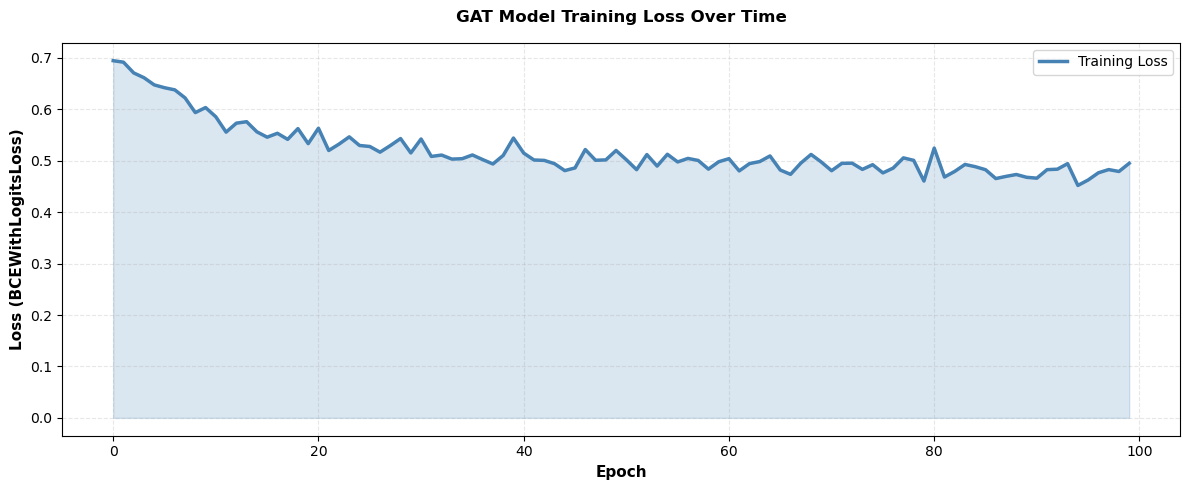

In [ ]:
model.train()
n_epochs = 100
losses = []

print(f"\nTraining for {n_epochs} epochs...")

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Forward pass
    node_embeddings = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)

    # Predict edge labels via dot product
    edge_logits = []
    for src_idx, dst_idx in zip(graph_data.edge_index[0], graph_data.edge_index[1]):
        logit = torch.dot(node_embeddings[src_idx], node_embeddings[dst_idx])
        edge_logits.append(logit)

    edge_logits = torch.stack(edge_logits)

    # Loss
    loss = criterion(edge_logits, edge_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{n_epochs} - Loss: {loss.item():.6f}")

print(f"\n✓ Training complete!")
print(f"  Final loss: {losses[-1]:.6f}")
if losses[0] != 0:
    improvement = (losses[0] - losses[-1]) / losses[0] * 100
    print(f"  Loss improvement: {improvement:.2f}%")

# Plot training loss
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses, linewidth=2.5, color='steelblue', label='Training Loss')
ax.fill_between(range(len(losses)), losses, alpha=0.2, color='steelblue')
ax.set_xlabel('Epoch', fontweight='bold', fontsize=11)
ax.set_ylabel('Loss (BCEWithLogitsLoss)', fontweight='bold', fontsize=11)
ax.set_title('GAT Model Training Loss Over Time', fontsize=12, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## EVALUATION & PAIR SCORING

In [ ]:
model.eval()

with torch.no_grad():
    node_embeddings = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)

    print(f"\nComputing GNN similarity scores for all pairs...")
    print(f"Evaluating {len(tickers)} × {len(tickers)} = {len(tickers)**2} combinations")
    print(f"Unique pairs: {len(tickers) * (len(tickers) - 1) // 2}\n")

    pair_scores_gnn = []

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            # Compute similarity
            similarity = torch.dot(node_embeddings[i], node_embeddings[j]).item()
            distance = torch.norm(node_embeddings[i] - node_embeddings[j]).item()

            ticker1 = tickers[i]
            ticker2 = tickers[j]

            # Find in training results
            mask = (
                ((all_pairs_results['Ticker1'] == ticker1) & (all_pairs_results['Ticker2'] == ticker2)) |
                ((all_pairs_results['Ticker1'] == ticker2) & (all_pairs_results['Ticker2'] == ticker1))
            )

            was_trained = mask.any()

            if was_trained:
                training_row = all_pairs_results[mask].iloc[0]
                actual_pnl = training_row.get('TotalRealizedPnL', np.nan)
                actual_win_rate = training_row.get('WinRate', np.nan)
                actual_trades = training_row.get('TotalTrades', np.nan)
            else:
                actual_pnl = None
                actual_win_rate = None
                actual_trades = None

            pair_scores_gnn.append({
                'Ticker1': ticker1,
                'Ticker2': ticker2,
                'GNNSimilarity': similarity,
                'EmbeddingDistance': distance,
                'WasTrained': was_trained,
                'ActualPnL': actual_pnl,
                'ActualWinRate': actual_win_rate,
                'ActualTrades': actual_trades
            })

    pair_scores_df = pd.DataFrame(pair_scores_gnn)
    pair_scores_df = pair_scores_df.sort_values('GNNSimilarity', ascending=False)

print(f"\n📊 Top 15 Pairs by GNN Similarity Score:\n")
top_15 = pair_scores_df[['Ticker1', 'Ticker2', 'GNNSimilarity', 'WasTrained',
                           'ActualPnL', 'ActualWinRate']].head(15)
print(top_15.to_string(index=False))

trained_pairs = pair_scores_df[pair_scores_df['WasTrained']]

print(f"\n📊 Top 10 Previously-Trained Pairs by GNN Score:\n")
if len(trained_pairs) > 0:
    top_trained = trained_pairs[['Ticker1', 'Ticker2', 'GNNSimilarity',
                                  'ActualPnL', 'ActualWinRate', 'ActualTrades']].head(10)
    print(top_trained.to_string(index=False))
else:
    print("  (No trained pairs found)")


Computing GNN similarity scores for all pairs...
Evaluating 39 × 39 = 1521 combinations
Unique pairs: 741


📊 Top 15 Pairs by GNN Similarity Score:

Ticker1 Ticker2  GNNSimilarity  WasTrained  ActualPnL  ActualWinRate
   BIIB    ENTA      38.421505       False        NaN            NaN
   ENTA    TMDX      31.209177       False        NaN            NaN
   BIIB    TMDX      30.445929       False        NaN            NaN
   ENTA    VRTX      28.107553        True  29.385727          100.0
   ENTA    NVAX      27.692730       False        NaN            NaN
   BIIB    VRTX      27.620018       False        NaN            NaN
   ENTA     LLY      27.258303       False        NaN            NaN
   BIIB    NVAX      27.168253       False        NaN            NaN
   BIIB     LLY      26.570507       False        NaN            NaN
   TMDX    VRTX      22.919987        True  28.895467          100.0
   NVAX    TMDX      22.699972       False        NaN            NaN
    LLY    TMDX      2

## CORRELATION ANALYSIS (PEARSON)


📈 GNN Score Correlation Analysis:

  Pearson Correlation (GNN Score vs Actual PnL):
    r = 0.5255
    Number of trained pairs: 36

  Pearson Correlation (GNN Score vs Win Rate):
    r = 0.0835


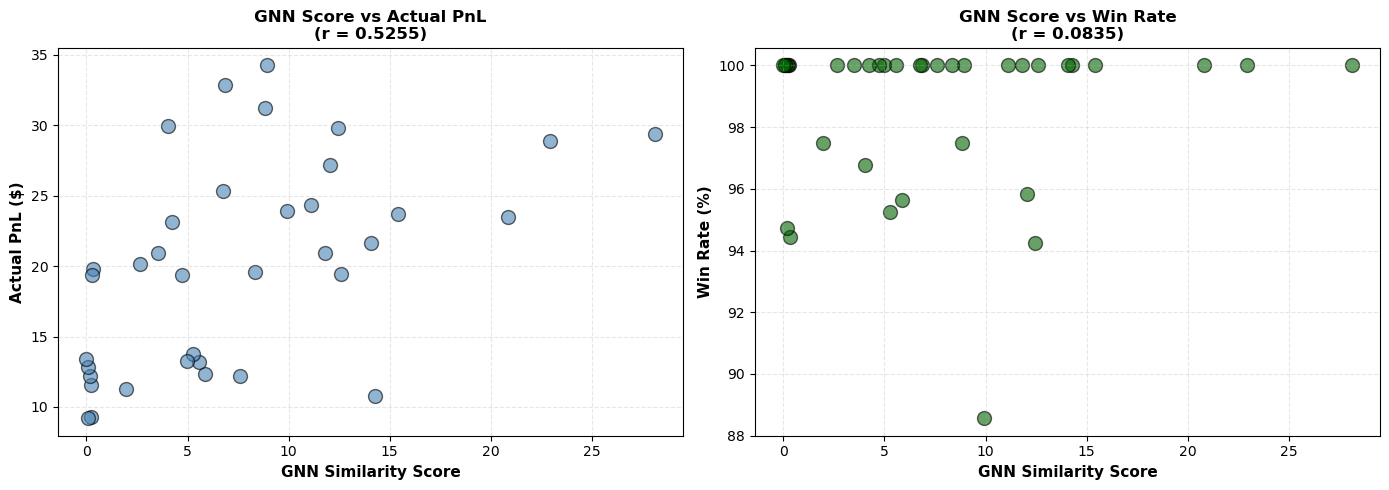

In [ ]:
print(f"\n📈 GNN Score Correlation Analysis:")

if len(trained_pairs) > 1:
    correlation_pnl = trained_pairs['GNNSimilarity'].corr(trained_pairs['ActualPnL'])
    correlation_winrate = trained_pairs['GNNSimilarity'].corr(trained_pairs['ActualWinRate'])

    print(f"\n  Pearson Correlation (GNN Score vs Actual PnL):")
    print(f"    r = {correlation_pnl:.4f}")
    print(f"    Number of trained pairs: {len(trained_pairs)}")

    print(f"\n  Pearson Correlation (GNN Score vs Win Rate):")
    print(f"    r = {correlation_winrate:.4f}")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: GNN Score vs PnL
    axes[0].scatter(
        trained_pairs['GNNSimilarity'],
        trained_pairs['ActualPnL'],
        alpha=0.6,
        s=100,
        color='steelblue',
        edgecolors='black',
        linewidth=1
    )
    axes[0].set_xlabel('GNN Similarity Score', fontweight='bold', fontsize=11)
    axes[0].set_ylabel('Actual PnL ($)', fontweight='bold', fontsize=11)
    axes[0].set_title(f'GNN Score vs Actual PnL\n(r = {correlation_pnl:.4f})',
                      fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, linestyle='--')

    # Plot 2: GNN Score vs Win Rate
    axes[1].scatter(
        trained_pairs['GNNSimilarity'],
        trained_pairs['ActualWinRate'],
        alpha=0.6,
        s=100,
        color='darkgreen',
        edgecolors='black',
        linewidth=1
    )
    axes[1].set_xlabel('GNN Similarity Score', fontweight='bold', fontsize=11)
    axes[1].set_ylabel('Win Rate (%)', fontweight='bold', fontsize=11)
    axes[1].set_title(f'GNN Score vs Win Rate\n(r = {correlation_winrate:.4f})',
                      fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

## SPEARMAN RANK CORRELATION


✓ Analyzing 36 trained pairs...

1. Computing Spearman Rank Correlation...

   Spearman Rank Correlation: 0.5629
   P-value: 0.000351
   Interpretation: ✓ GOOD: GNN rankings correlate with actual PnL

2. Computing Precision Metrics...
   Precision (Top 5): 5/5 = 100.0%
   Precision (Top 10): 10/10 = 100.0%
   Precision (Top 20): 20/20 = 100.0%

3. Detailed Rankings Comparison (Top 15 Trained Pairs):
--------------------------------------------------------------------------------------------------------------
Ticker1 Ticker2  GNNRank  GNNSimilarity  ActualPnLRank  ActualPnL  ActualWinRate
   ENTA    VRTX      1.0      28.107553            6.0  29.385727     100.000000
   TMDX    VRTX      2.0      22.919987            7.0  28.895467     100.000000
   NVAX    VRTX      3.0      20.829235           13.0  23.475387     100.000000
   AMGN    ENTA      4.0      15.418037           12.0  23.699715     100.000000
    AZN    TMDX      5.0      14.259733           34.0  10.808530     100.000000

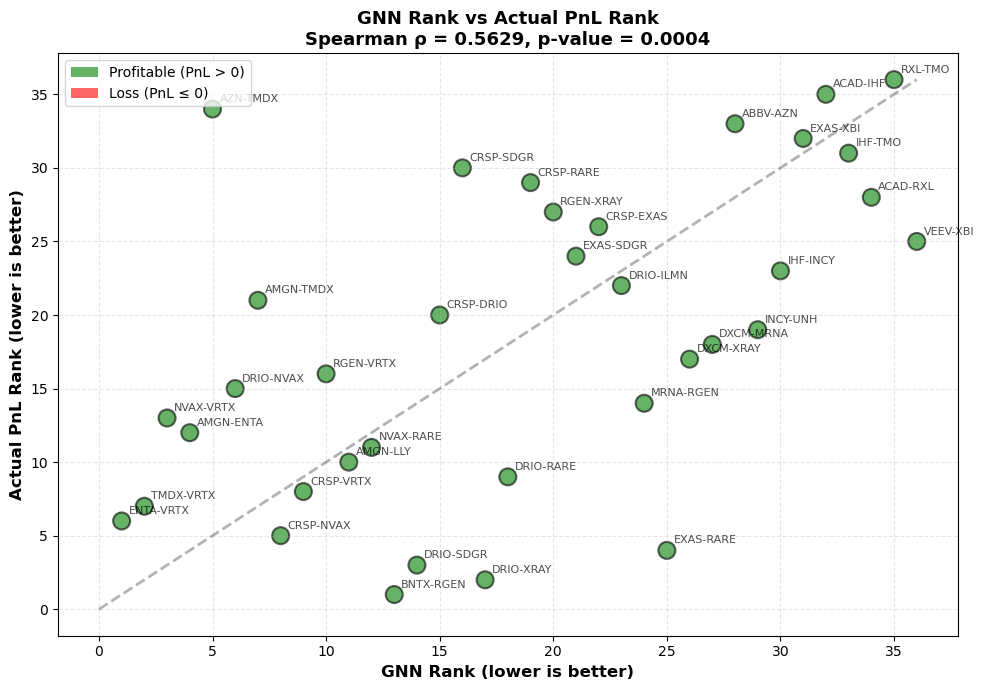

In [ ]:
trained_with_scores = pair_scores_df[pair_scores_df['WasTrained'] == True].copy()

if len(trained_with_scores) > 1:
    print(f"\n✓ Analyzing {len(trained_with_scores)} trained pairs...")

    # 1. Rank Correlation
    print("\n1. Computing Spearman Rank Correlation...")

    trained_with_scores['GNNRank'] = trained_with_scores['GNNSimilarity'].rank(ascending=False)
    trained_with_scores['ActualPnLRank'] = trained_with_scores['ActualPnL'].rank(ascending=False)

    spearman_corr, p_value = spearmanr(
        trained_with_scores['GNNRank'],
        trained_with_scores['ActualPnLRank']
    )

    print(f"\n   Spearman Rank Correlation: {spearman_corr:.4f}")
    print(f"   P-value: {p_value:.6f}")

    # Interpretation
    if spearman_corr > 0.6:
        interpretation = "✓ EXCELLENT: GNN rankings strongly correlate with actual PnL!"
    elif spearman_corr > 0.4:
        interpretation = "✓ GOOD: GNN rankings correlate with actual PnL"
    elif spearman_corr > 0.2:
        interpretation = "⚠ FAIR: Weak correlation - GNN captured some patterns"
    else:
        interpretation = "✗ WEAK: GNN not predicting PnL well"

    print(f"   Interpretation: {interpretation}")

    # 2. Precision Metrics
    print("\n2. Computing Precision Metrics...")

    top_n_values = [5, 10, 20]
    precision_results = []

    for top_n in top_n_values:
        top_n_gnn = pair_scores_df[pair_scores_df['WasTrained'] == True].head(top_n)
        if len(top_n_gnn) > 0:
            profitable_count = (top_n_gnn['ActualPnL'] > 0).sum()
            precision = profitable_count / len(top_n_gnn)
            print(f"   Precision (Top {top_n}): {profitable_count}/{len(top_n_gnn)} = {precision*100:.1f}%")
            precision_results.append({
                'Top_N': top_n,
                'Profitable': profitable_count,
                'Total': len(top_n_gnn),
                'Precision': precision * 100
            })

    # 3. Detailed Rankings Comparison
    print("\n3. Detailed Rankings Comparison (Top 15 Trained Pairs):")
    print("-" * 110)

    comparison_display = trained_with_scores[['Ticker1', 'Ticker2', 'GNNRank', 'GNNSimilarity',
                                               'ActualPnLRank', 'ActualPnL', 'ActualWinRate']].head(15)
    print(comparison_display.to_string(index=False))

    print("\n" + "-" * 110)

    # 4. Statistical Significance
    print("\n4. Statistical Significance:")

    if p_value < 0.05:
        print(f"   ✓ SIGNIFICANT: p-value = {p_value:.6f} < 0.05")
        print(f"     → GNN ranking is statistically significant!")
    elif p_value < 0.10:
        print(f"   ⚠ MARGINALLY SIGNIFICANT: p-value = {p_value:.6f} < 0.10")
        print(f"     → Weak but possible relationship")
    else:
        print(f"   ✗ NOT SIGNIFICANT: p-value = {p_value:.6f} >= 0.05")
        print(f"     → No statistically significant relationship")

    # 5. Save Validation Results
    print("\n5. Saving validation results...")

    validation_results = pd.DataFrame({
        'Metric': [
            'Spearman Correlation',
            'P-Value',
            'Sample Size',
            'Interpretation',
            'Statistically Significant'
        ],
        'Value': [
            f'{spearman_corr:.4f}',
            f'{p_value:.6f}',
            f'{len(trained_with_scores)}',
            interpretation,
            'Yes' if p_value < 0.05 else 'No'
        ]
    })

    validation_results.to_csv('gnn_validation_metrics.csv', index=False)
    print(f"   ✓ Saved: gnn_validation_metrics.csv")

    if precision_results:
        precision_df = pd.DataFrame(precision_results)
        precision_df.to_csv('gnn_precision_metrics.csv', index=False)
        print(f"   ✓ Saved: gnn_precision_metrics.csv")

    # 6. Visualization: Rank Correlation
    print("\n6. Creating rank correlation visualization...")

    fig, ax = plt.subplots(figsize=(10, 7))

    colors = ['green' if pnl > 0 else 'red' for pnl in trained_with_scores['ActualPnL']]

    scatter = ax.scatter(
        trained_with_scores['GNNRank'],
        trained_with_scores['ActualPnLRank'],
        s=150,
        alpha=0.6,
        c=colors,
        edgecolors='black',
        linewidth=1.5
    )

    # Perfect correlation line
    max_rank = max(trained_with_scores['GNNRank'].max(),
                   trained_with_scores['ActualPnLRank'].max())
    ax.plot([0, max_rank], [0, max_rank], 'k--', alpha=0.3, linewidth=2, label='Perfect Correlation')

    # Annotations
    for idx, row in trained_with_scores.iterrows():
        ax.annotate(
            f"{row['Ticker1']}-{row['Ticker2']}",
            xy=(row['GNNRank'], row['ActualPnLRank']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.7
        )

    ax.set_xlabel('GNN Rank (lower is better)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual PnL Rank (lower is better)', fontweight='bold', fontsize=12)
    ax.set_title(f'GNN Rank vs Actual PnL Rank\nSpearman ρ = {spearman_corr:.4f}, p-value = {p_value:.4f}',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend()

    # Color legend
    legend_elements = [
        Patch(facecolor='green', alpha=0.6, label='Profitable (PnL > 0)'),
        Patch(facecolor='red', alpha=0.6, label='Loss (PnL ≤ 0)')
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    plt.savefig('gnn_spearman_rank_correlation.png', dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved: gnn_spearman_rank_correlation.png")
    plt.show()

else:
    print("\n⚠ Warning: Not enough trained pairs for statistical validation")
    print(f"   Need at least 2 trained pairs, but found {len(trained_with_scores)}")

## SAVE RESULTS

In [ ]:
# Save full results
pair_scores_df.to_csv('gnn_all_pairs_scores.csv', index=False)
print(f"\n✓ Saved: gnn_all_pairs_scores.csv")
print(f"  Total pairs: {len(pair_scores_df)}")

# Save trained pairs only (deployment candidates)
trained_only = pair_scores_df[pair_scores_df['WasTrained'] == True].sort_values('GNNSimilarity', ascending=False)
trained_only.to_csv('gnn_trained_pairs_ranked.csv', index=False)
print(f"✓ Saved: gnn_trained_pairs_ranked.csv")
print(f"  Previously trained pairs: {len(trained_only)}")


✓ Saved: gnn_all_pairs_scores.csv
  Total pairs: 741
✓ Saved: gnn_trained_pairs_ranked.csv
  Previously trained pairs: 36


## RECOMMENDATIONS FOR UNTRAINED PAIRS

In [ ]:
# 1. Identify untrained pairs
print("\n1. Identifying untrained pairs...")

trained_pairs_set = set()
for idx, row in all_pairs_results.iterrows():
    ticker1 = row['Ticker1']
    ticker2 = row['Ticker2']
    trained_pairs_set.add((ticker1, ticker2))
    trained_pairs_set.add((ticker2, ticker1))

print(f"   ✓ Found {len(trained_pairs_set)//2} trained pairs")

# 2. Filter untrained pairs
print("\n2. Filtering untrained pairs...")

untrained_list = []
for idx, row in pair_scores_df.iterrows():
    pair = (row['Ticker1'], row['Ticker2'])
    if pair not in trained_pairs_set:
        untrained_list.append(row)

untrained_df = pd.DataFrame(untrained_list)

if len(untrained_df) > 0:
    untrained_df = untrained_df.sort_values('GNNSimilarity', ascending=False)
    print(f"   ✓ Found {len(untrained_df)} untrained pairs")
else:
    print(f"   ⚠ No untrained pairs found")

# 3. Add recommendation levels
print("\n3. Adding recommendation levels...")

def get_recommendation(gnn_score):
    """Assign recommendation based on GNN similarity score."""
    if gnn_score >= 0.7:
        return "HIGHLY RECOMMENDED"
    elif gnn_score >= 0.5:
        return "RECOMMENDED"
    elif gnn_score >= 0.3:
        return "WORTH TRYING"
    else:
        return "LOW CONFIDENCE"

if len(untrained_df) > 0:
    untrained_df['Recommendation'] = untrained_df['GNNSimilarity'].apply(get_recommendation)
    untrained_df['ConfidenceScore'] = untrained_df['GNNSimilarity']

    # 4. Display top recommendations
    print("\n4. TOP 20 RECOMMENDED PAIRS (Not Yet Trained):")
    print("-" * 100)

    top_recommendations = untrained_df.head(20)[['Ticker1', 'Ticker2', 'GNNSimilarity',
                                                   'EmbeddingDistance', 'Recommendation']]

    print(f"{'Rank':<6}{'Pair':<15}{'GNN Score':<12}{'Distance':<12}{'Recommendation':<20}")
    print("-" * 100)

    for rank, (idx, row) in enumerate(top_recommendations.iterrows(), 1):
        pair_name = f"{row['Ticker1']}-{row['Ticker2']}"
        print(f"{rank:<6}{pair_name:<15}{row['GNNSimilarity']:<12.4f}{row['EmbeddingDistance']:<12.4f}"
              f"{row['Recommendation']:<20}")

    print("-" * 100)

    # 5. Summary statistics
    print("\n5. RECOMMENDATION DISTRIBUTION:")

    rec_counts = untrained_df['Recommendation'].value_counts()
    total_untrained = len(untrained_df)

    for rec_level in ['HIGHLY RECOMMENDED', 'RECOMMENDED', 'WORTH TRYING', 'LOW CONFIDENCE']:
        count = rec_counts.get(rec_level, 0)
        percentage = (count / total_untrained * 100) if total_untrained > 0 else 0
        print(f"   {rec_level:<20}: {count:>3} pairs ({percentage:>5.1f}%)")

    # 6. Save recommendations
    print("\n6. Saving recommendations...")

    top_20_recommendations = untrained_df.head(20)[['Ticker1', 'Ticker2', 'GNNSimilarity',
                                                      'EmbeddingDistance', 'Recommendation']]
    top_20_recommendations.to_csv('gnn_recommended_new_pairs.csv', index=False)
    print(f"   ✓ Saved top 20 recommendations to: gnn_recommended_new_pairs.csv")

    untrained_df[['Ticker1', 'Ticker2', 'GNNSimilarity', 'EmbeddingDistance', 'Recommendation']].to_csv(
        'gnn_all_untrained_pairs_ranked.csv', index=False
    )
    print(f"   ✓ Saved all untrained pairs to: gnn_all_untrained_pairs_ranked.csv ({len(untrained_df)} pairs)")

    # 7. Next steps
    print("\n7. RECOMMENDED NEXT STEPS:")
    print("   → Run Notebook 3 with these pairs to validate predictions")
    print("   → Compare actual results with GNN recommendations")
    print("   → Use top recommended pairs for portfolio construction")

else:
    print("\n⚠ No untrained pairs to recommend")
    print("   All possible pairs have already been trained")


1. Identifying untrained pairs...
   ✓ Found 36 trained pairs

2. Filtering untrained pairs...
   ✓ Found 705 untrained pairs

3. Adding recommendation levels...

4. TOP 20 RECOMMENDED PAIRS (Not Yet Trained):
----------------------------------------------------------------------------------------------------
Rank  Pair           GNN Score   Distance    Recommendation      
----------------------------------------------------------------------------------------------------
1     BIIB-ENTA      38.4215     0.9232      HIGHLY RECOMMENDED  
2     ENTA-TMDX      31.2092     1.4040      HIGHLY RECOMMENDED  
3     BIIB-TMDX      30.4459     1.9108      HIGHLY RECOMMENDED  
4     ENTA-NVAX      27.6927     2.1697      HIGHLY RECOMMENDED  
5     BIIB-VRTX      27.6200     2.1107      HIGHLY RECOMMENDED  
6     ENTA-LLY       27.2583     2.0220      HIGHLY RECOMMENDED  
7     BIIB-NVAX      27.1683     2.4310      HIGHLY RECOMMENDED  
8     BIIB-LLY       26.5705     2.3701      HIGHLY RECOMME